In [308]:
import geopandas as gpd
from pathlib import Path
import os
import numpy as np
from pyproj import Transformer
import requests
import time
import matplotlib.pyplot as plt

In [3]:
REPO_ROOT = Path(os.getcwd()).parent
DATA_PATH  = REPO_ROOT / "data" / "backtest" / "hist_data.parquet"

# I. Wild Fire Area Analysis

<Axes: ylabel='Frequency'>

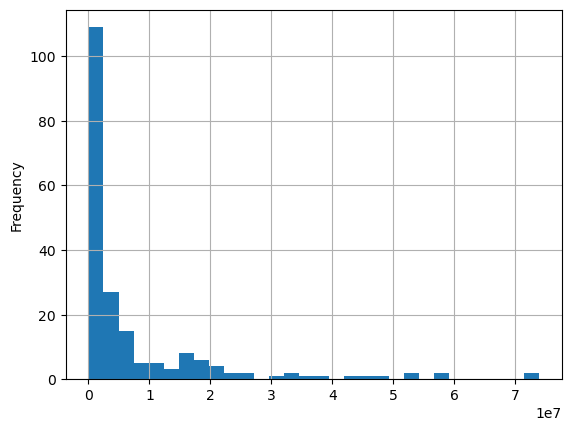

In [8]:
gdf = gpd.read_parquet(DATA_PATH)

gdf_metric = gdf.to_crs(epsg=2154)

areas = gdf_metric.geometry.area

areas.plot.hist(bins= 30, grid = True)

In [9]:
area_data = (gdf.assign(polygon_area = gdf.geometry.area)[["wildfire_id", "prop_step","polygon_area"]]
            .set_index(["wildfire_id", "prop_step"]))

gdf = gdf.merge(area_data, how = 'left', on = ["wildfire_id", "prop_step"])

In [10]:
gdf[["wildfire_id", 'prop_step', 'polygon_area']].query("wildfire_id == 45")

,wildfire_id,prop_step,polygon_area
170,45,0,3.136548e+00
171,45,1,5.548240e+06
172,45,2,1.873395e+07
173,45,3,3.326883e+07
174,45,4,3.605958e+07
175,45,5,4.342728e+07
176,45,6,5.850543e+07


In [11]:
gdf["wildfire_id"].value_counts()

wildfire_id
1     7
45    7
6     6
20    5
4     5
7     5
10    5
12    5
17    5
30    5
35    5
44    5
3     4
16    4
15    4
18    4
25    4
26    4
27    4
28    4
31    4
34    4
37    4
41    4
42    4
50    4
51    4
2     3
5     3
8     3
9     3
11    3
13    3
14    3
19    3
21    3
22    3
23    3
24    3
29    3
32    3
33    3
36    3
38    3
39    3
40    3
43    3
46    3
47    3
48    3
49    3
52    3
Name: count, dtype: int64

In [12]:
%cd ..
from simulators.backtest import FireForestViz


/home/perann/Bureau/MVA/Interactions/interactions


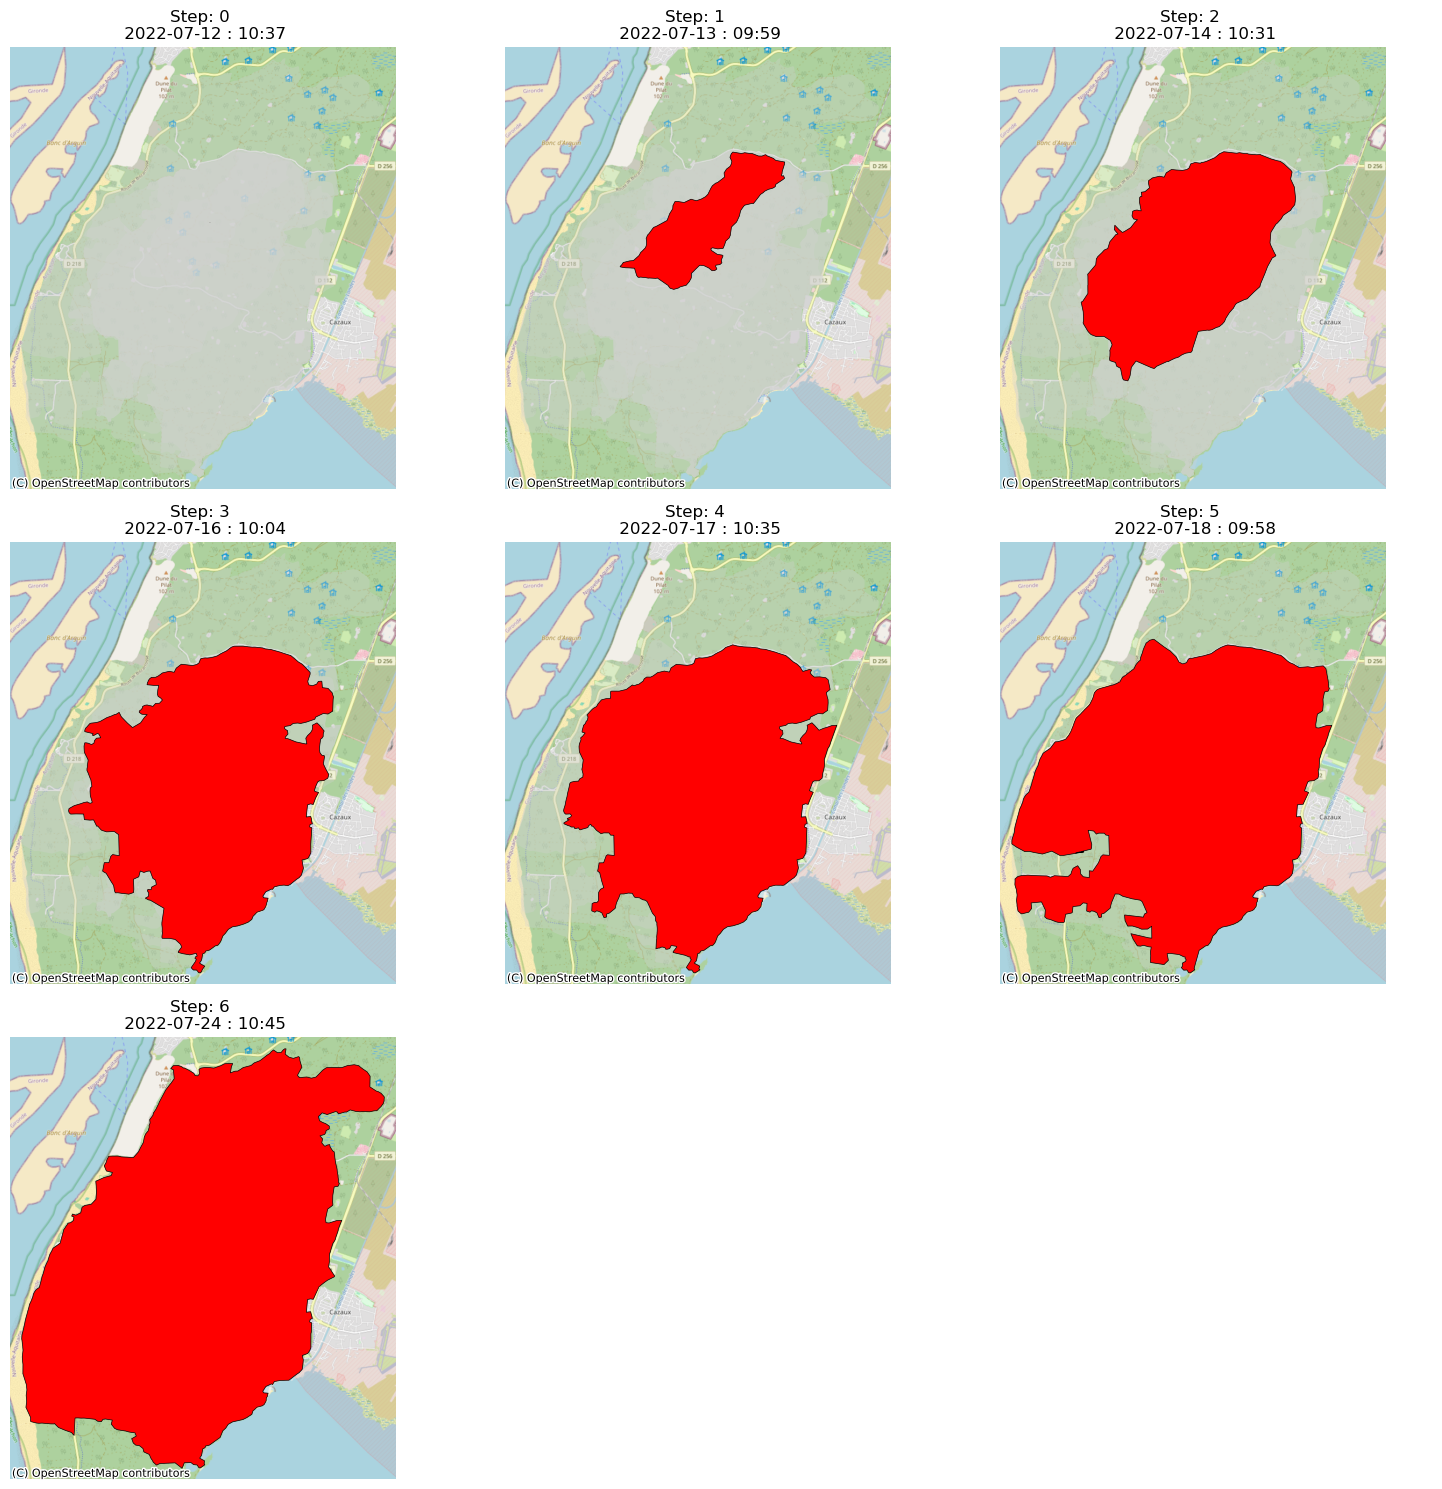

In [13]:
FireForestViz(45)

In [14]:
def generate_covering_grid(wildfire_id : int, margin : int, resolution : int):
    
    minx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[0] - margin
    miny = gdf[gdf.wildfire_id == wildfire_id].total_bounds[1] - margin
    maxx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[2] + margin
    maxy = gdf[gdf.wildfire_id == wildfire_id].total_bounds[3] + margin

    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)

    x_centers = minx + (np.arange(width) * resolution) + (resolution / 2)
    y_centers = miny + (np.arange(height) * resolution) + (resolution / 2)

    grid_x, grid_y = np.meshgrid(x_centers, y_centers)

    return grid_x, grid_y

In [15]:
grid_x, grid_y = generate_covering_grid(45, 400, 200)

# II. Getting Weather data

In [16]:
def get_weather_grid(lat_flat, lon_flat, height, width, date_str, hour_idx=10):
    temps = []
    wind_speeds = []
    wind_dirs = []
    chunk_size = 50 
    i = 0
    
    print(f"Récupération météo pour le {date_str} à {hour_idx}h...")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = (f"https://archive-api.open-meteo.com/v1/archive?"
               f"latitude={lats_str}&longitude={lons_str}&"
               f"start_date={date_str}&end_date={date_str}&"
               f"hourly=temperature_2m,wind_speed_10m,wind_direction_10m&"
               f"timezone=auto")
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                for point_data in data:
                    temps.append(point_data['hourly']['temperature_2m'][hour_idx])
                    wind_speeds.append(point_data['hourly']['wind_speed_10m'][hour_idx])
                    wind_dirs.append(point_data['hourly']['wind_direction_10m'][hour_idx])
                
                i += chunk_size
                print(f"Météo : {len(temps)}/{len(lat_flat)} points.")
                time.sleep(0.5)
                
            elif response.status_code == 429:
                print("Limite API. Pause 62s...")
                time.sleep(62)
            else:
                print(f"Erreur : {data.get('reason')}")
                break
        except Exception as e:
            print(f"Erreur connexion : {e}")
            time.sleep(5)

    res_temps = np.flipud(np.array(temps).reshape((height, width)))
    res_wind_speed = np.flipud(np.array(wind_speeds).reshape((height, width)))
    res_wind_dir = np.flipud(np.array(wind_dirs).reshape((height, width)))
    
    return res_temps, res_wind_speed, res_wind_dir

In [17]:
gdf[gdf.wildfire_id == 45][["date", "prop_step"]]

,date,prop_step
170,2022-07-12 10:37:25,0
171,2022-07-13 09:59:05,1
172,2022-07-14 10:31:49,2
173,2022-07-16 10:04:17,3
174,2022-07-17 10:35:24,4
175,2022-07-18 09:58:39,5
176,2022-07-24 10:45:44,6


In [18]:
BACKTEST_DATA_PATH = REPO_ROOT / "data" / "backtest" / "fire_example_45"
BACKTEST_DATA_PATH.mkdir(parents=True, exist_ok=True)

transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
lon_flat, lat_flat = transformer.transform(grid_x.flatten(), grid_y.flatten())

height, width = grid_x.shape

dates = gdf[gdf.wildfire_id == 45]["date"].dt.strftime("%Y-%m-%d").unique()

for date in dates[1:]:
    m_temp, m_wind_v, m_wind_d = get_weather_grid(lat_flat, lon_flat, height, width, date, 10)
    
    np.save(BACKTEST_DATA_PATH / f"{date}_temperature.npy", m_temp)
    np.save(BACKTEST_DATA_PATH / f"{date}_wind_val.npy", m_wind_v)
    np.save(BACKTEST_DATA_PATH / f"{date}_wind_direction.npy", m_wind_d)

Récupération météo pour le 2022-07-13 à 10h...
Météo : 50/2916 points.
Météo : 100/2916 points.
Météo : 150/2916 points.
Météo : 200/2916 points.
Météo : 250/2916 points.
Météo : 300/2916 points.


KeyboardInterrupt: 

# III. Getting altitude data

In [222]:
def get_elevation_grid(lat_flat, lon_flat, height, width):
    elevations = []
    chunk_size = 50  
    i = 0
    
    print(f"Début de la récupération : {len(lat_flat)} points à traiter.")

    while i < len(lat_flat):
        lats_chunk = lat_flat[i : i + chunk_size]
        lons_chunk = lon_flat[i : i + chunk_size]
        
        lats_str = ",".join([f"{l:.5f}" for l in lats_chunk])
        lons_str = ",".join([f"{l:.5f}" for l in lons_chunk])
        
        url = f"https://api.open-meteo.com/v1/elevation?latitude={lats_str}&longitude={lons_str}"
        
        try:
            response = requests.get(url)
            data = response.json()
            
            if response.status_code == 200:
                elevations.extend(data['elevation'])
                print(f"Succès : {len(elevations)}/{len(lat_flat)} points récupérés.")
                i += chunk_size
                time.sleep(1) 
                
            elif response.status_code == 429 or (data.get('error') and 'limit exceeded' in data.get('reason', '')):
                print(f"\n[!] Limite API atteinte au point {i}. Pause de 62 secondes...")
                time.sleep(62) 
            else:
                print(f"Erreur API inattendue : {data.get('reason')}")
                break
                
        except Exception as e:
            print(f"Erreur de connexion : {e}. Nouvelle tentative dans 5 secondes...")
            time.sleep(5)

   
    if len(elevations) >= len(lat_flat):
        # On s'assure d'avoir la taille exacte (au cas où le dernier chunk dépasse)
        final_elev = np.array(elevations[:len(lat_flat)]).reshape((height, width))
        # On inverse le sens pour que le haut de la matrice soit le Nord
        return np.flipud(final_elev)
    else:
        return None


matrix_elevation = get_elevation_grid(lat_flat, lon_flat, height, width)
np.save(BACKTEST_DATA_PATH / "altitude.npy", matrix_elevation)

Début de la récupération : 2916 points à traiter.
Succès : 50/2916 points récupérés.
Succès : 100/2916 points récupérés.
Succès : 150/2916 points récupérés.
Succès : 200/2916 points récupérés.
Succès : 250/2916 points récupérés.
Succès : 300/2916 points récupérés.
Succès : 350/2916 points récupérés.
Succès : 400/2916 points récupérés.
Succès : 450/2916 points récupérés.
Succès : 500/2916 points récupérés.
Succès : 550/2916 points récupérés.
Succès : 600/2916 points récupérés.

[!] Limite API atteinte au point 600. Pause de 62 secondes...
Succès : 650/2916 points récupérés.
Succès : 700/2916 points récupérés.
Succès : 750/2916 points récupérés.
Succès : 800/2916 points récupérés.
Succès : 850/2916 points récupérés.
Succès : 900/2916 points récupérés.
Succès : 950/2916 points récupérés.
Succès : 1000/2916 points récupérés.
Succès : 1050/2916 points récupérés.
Succès : 1100/2916 points récupérés.
Succès : 1150/2916 points récupérés.
Succès : 1200/2916 points récupérés.

[!] Limite API att

FileNotFoundError: [Errno 2] No such file or directory: '/home/perann/Bureau/MVA/Interactions/interactions/data/backtest/fire_example/altitude.npy'

## IV. Test Cellular automaton

In [19]:
from simulators.CellularAutomaton import CellularAutomaton

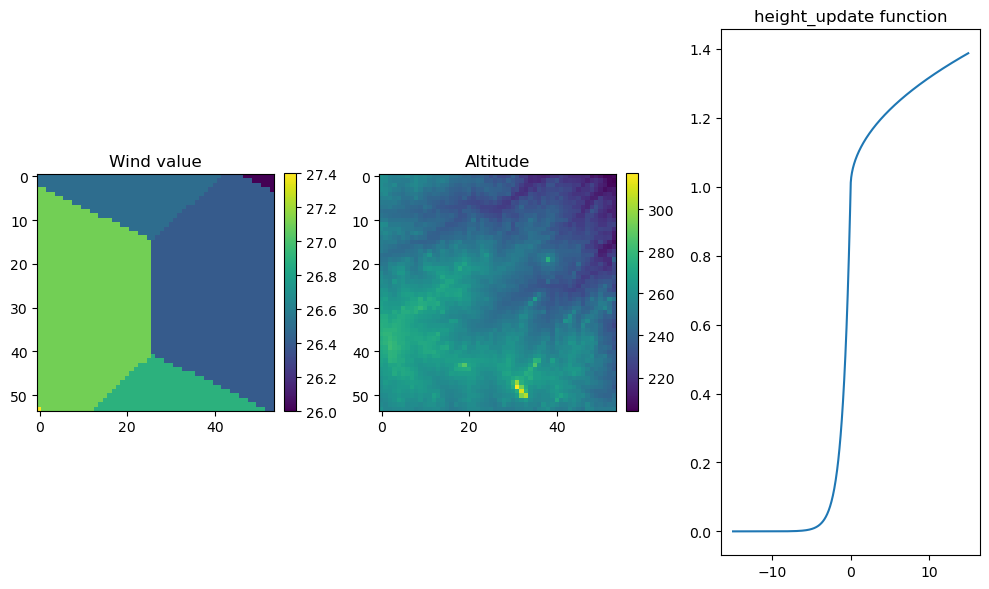

In [ ]:
wind_grid = np.load("data/backtest/fire_example_45/2022-07-12_wind_val.npy")
altitude = np.load("/home/perann/Bureau/MVA/Interactions/interactions/data/backtest/fire_example_45/altitude.npy")

def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10 
    
    
fig, ax = plt.subplots(1,3, figsize = (10, 6))

im0 = ax[0].imshow(wind_grid, cmap= "viridis")
ax[0].set_title("Wind value")
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)


im1 = ax[1].imshow(altitude, cmap= "viridis")
ax[1].set_title("Altitude")
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

x = np.linspace(-15, 15, 1000)
y = [height_update(val) for val in x]
ax[2].plot(x,y)
ax[2].set_title("height_update function")

plt.tight_layout() 
plt.show()


In [267]:
def compute_start_point_coord(wildfire_id: int, margin: int, resolution: int):


    fire_data = gdf[gdf.wildfire_id == wildfire_id]
    total_bounds = fire_data.total_bounds
    minx = total_bounds[0] - margin
    maxy = total_bounds[3] + margin 

    start_geom = fire_data.sort_values('prop_step').iloc[0].geometry.centroid
    start_x, start_y = start_geom.x, start_geom.y


    col_idx = int((start_x - minx) // resolution)
    
    row_idx = int((maxy - start_y) // resolution)

    return row_idx, col_idx

start_row, start_col = compute_start_point_coord(45, 400, 200)

In [268]:
m = np.min(wind_grid)
M = np.max(wind_grid)

scaled_wind = (wind_grid - m)/(M-m) + 1

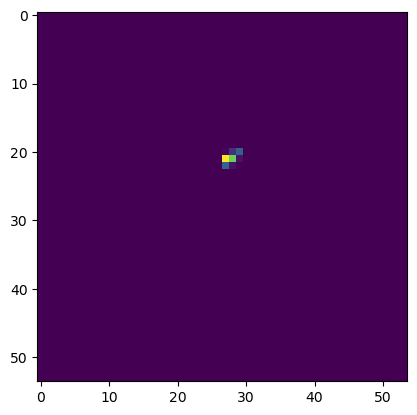

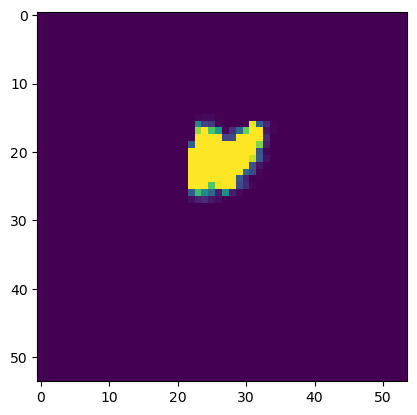

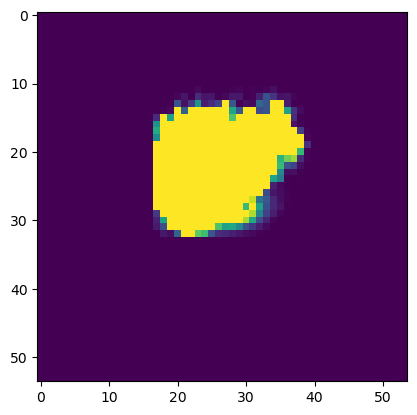

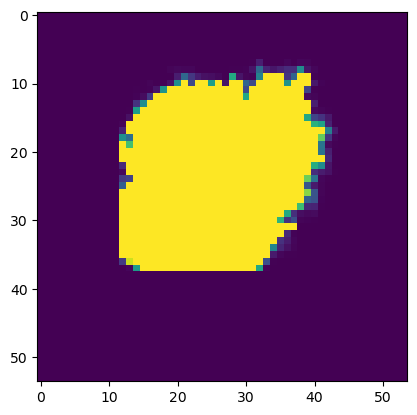

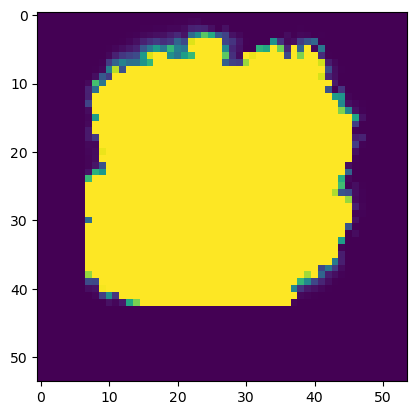

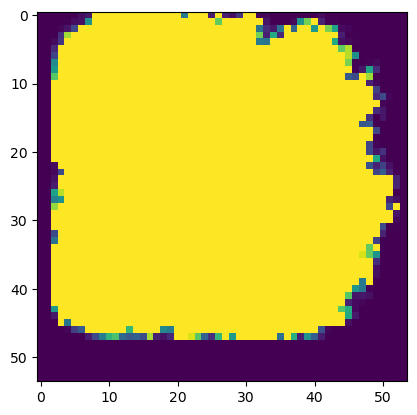

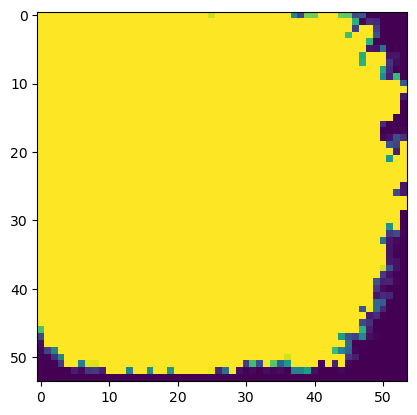

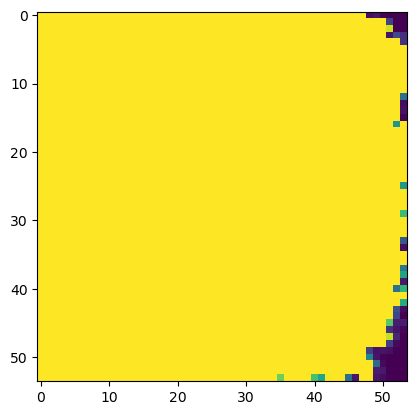

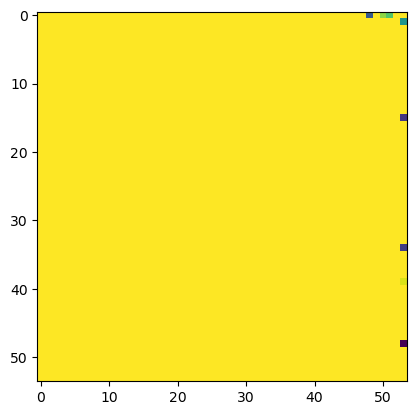

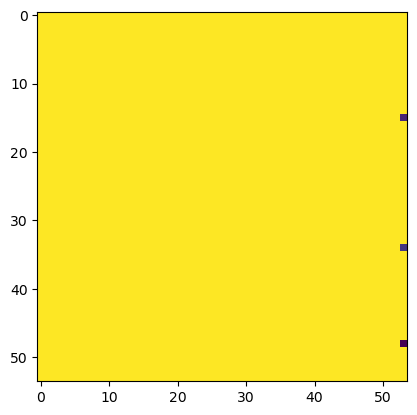

In [269]:
Model = CellularAutomaton(height, width,scaled_wind, altitude, height_update)
Model.initialize_ignition([(start_row, start_col)], [0.4])

current_state = Model.get_state()

for step in range(50):
    Model.evolve()
    if step % 5 == 0:
        current_state = Model.get_state()
        plt.imshow(current_state)
        plt.show()

# V. Translating firepropagation into matrix

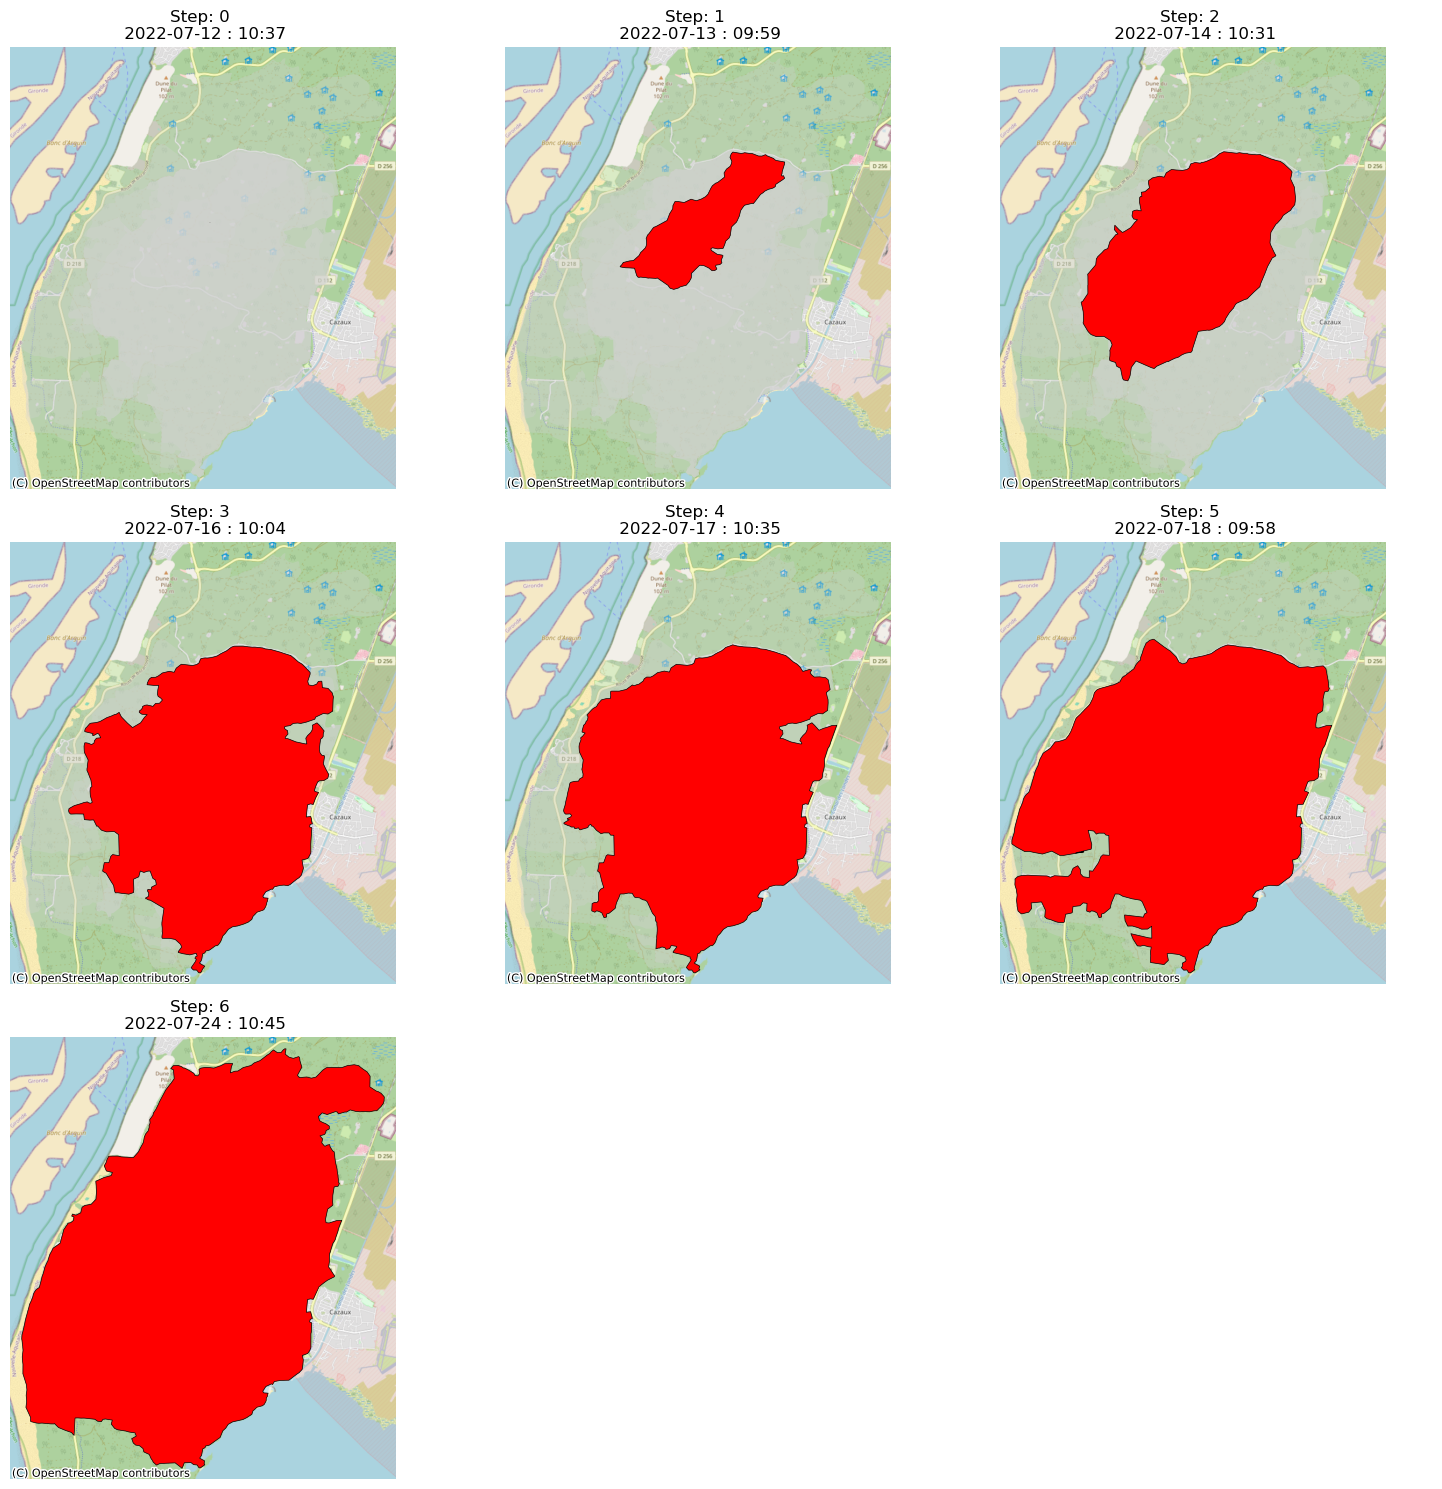

In [105]:
FireForestViz(45)

In [319]:
def generate_matrix_for_one_step(wildfire_id :int, step : int, bounds, resolution, gdf):
    """
    Generates a rasterized grid representing the burned area for a specific wildfire time step.

    The function creates a matrix where each cell value represents the fraction of 
    the cell's area that has been burned, normalized between 0.0 and 1.0.

    Args:
        wildfire_id (int): Unique identifier of the wildfire.
        step (int): The specific propagation step to process.
        bounds (list): List of coordinates [minx, miny, maxx, maxy] defining the grid extent.
        resolution (float): The size of each grid cell in map units.
        gdf (GeoDataFrame): Spatial data containing wildfire geometries and attributes.

    Returns:
        np.ndarray: A 2D numpy array representing the burned intensity grid.
    """

    minx, miny, maxx, maxy = bounds
    width = int((maxx - minx) / resolution)
    height = int((maxy - miny) / resolution)

    step_gdf = gdf[(gdf.wildfire_id == wildfire_id) & (gdf.prop_step == step)]

    matrix = np.zeros((height, width))
    cell_area = resolution ** 2

    x_coords = np.arange(minx, maxx, resolution)
    y_coords = np.arange(maxy, miny, -resolution)


    for i, y in enumerate(y_coords):
        for j, x in enumerate(x_coords):
            cell = box(x, y - resolution, x + resolution, y)
            inter = step_gdf.intersection(cell)
            if not inter.is_empty.any():
                area_burned = inter.area.sum()
                matrix[i, j] = min(area_burned / cell_area, 1.0)
                
    return matrix

def generate_wildfire_propagation_grids(wildfire_id, margin, resolution, gdf):
    """
    Computes a sequence of propagation matrices for a given wildfire across all time steps.

    This function determines the global bounding box of the wildfire (including a margin),
    identifies all unique propagation steps, and generates a matrix for each step.

    Args:
        wildfire_id (int): Unique identifier of the wildfire.
        margin (float): Extra space added around the wildfire's total bounds.
        resolution (float): The size of each grid cell in map units.
        gdf (GeoDataFrame): Spatial data containing wildfire geometries.

    Returns:
        list[np.ndarray]: A list of 2D numpy arrays, one for each propagation step.
    """
    minx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[0] - margin
    miny = gdf[gdf.wildfire_id == wildfire_id].total_bounds[1] - margin
    maxx = gdf[gdf.wildfire_id == wildfire_id].total_bounds[2] + margin
    maxy = gdf[gdf.wildfire_id == wildfire_id].total_bounds[3] + margin
    steps_to_check = gdf[gdf.wildfire_id == wildfire_id].prop_step.unique()
    bounds = [minx, miny, maxx, maxy]
    matrices = []

    for step in steps_to_check:
        matrices.append(generate_matrix_for_one_step(wildfire_id,step , bounds, resolution,gdf))
    return matrices

def plot_matrix_wildfire_propagation(liste_matrices, n_cols=3):
    """
    Visualizes the sequence of wildfire propagation matrices in a grid of subplots.

    Each matrix is displayed using a color map (viridis) where values range from 
    0 (not burned) to 1 (fully burned).

    Args:
        liste_matrices (list[np.ndarray]): List of 2D numpy arrays to visualize.
        n_cols (int, optional): Number of columns in the plot grid. Defaults to 3.

    Returns:
        None: Displays the plot using matplotlib.
    """
    n_images = len(liste_matrices)
    n_rows = (n_images + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    if n_rows == 1:
        axes_flat = axes
    else:
        axes_flat = axes.flatten()
    
    im = None
    for i in range(len(axes_flat)):
        if i < n_images:
            im = axes_flat[i].imshow(liste_matrices[i], cmap='viridis', 
                                     vmin=0, vmax=1)
            axes_flat[i].set_title(f"Matrice {i}")
        else:
            axes_flat[i].axis('off')
    fig.colorbar(im, ax=axes_flat.tolist(), shrink=0.6, label='Échelle [0, 1]')
    plt.show()


def FireForestVizMatrix(wildfire_id : int, margin : int, resolution : int, gdf) -> None:
    """
    Orchestrates the full pipeline to generate and visualize wildfire propagation grids.

    This high-level function fetches the burned area data for a specific fire, 
    converts the spatial geometries into a sequence of intensity matrices based 
    on the provided resolution, and generates a comparative visualization.

    Args:
        wildfire_id (int): Unique identifier of the wildfire to visualize.
        margin (int): Buffer distance added around the wildfire extent to provide context.
        resolution (int): The spatial resolution (cell size) for the output matrices.

    Returns:
        None: This function outputs a Matplotlib plot directly.
    """
     
    matrices = generate_wildfire_propagation_grids(wildfire_id, margin, resolution,gdf)
    plot_matrix_wildfire_propagation(matrices)


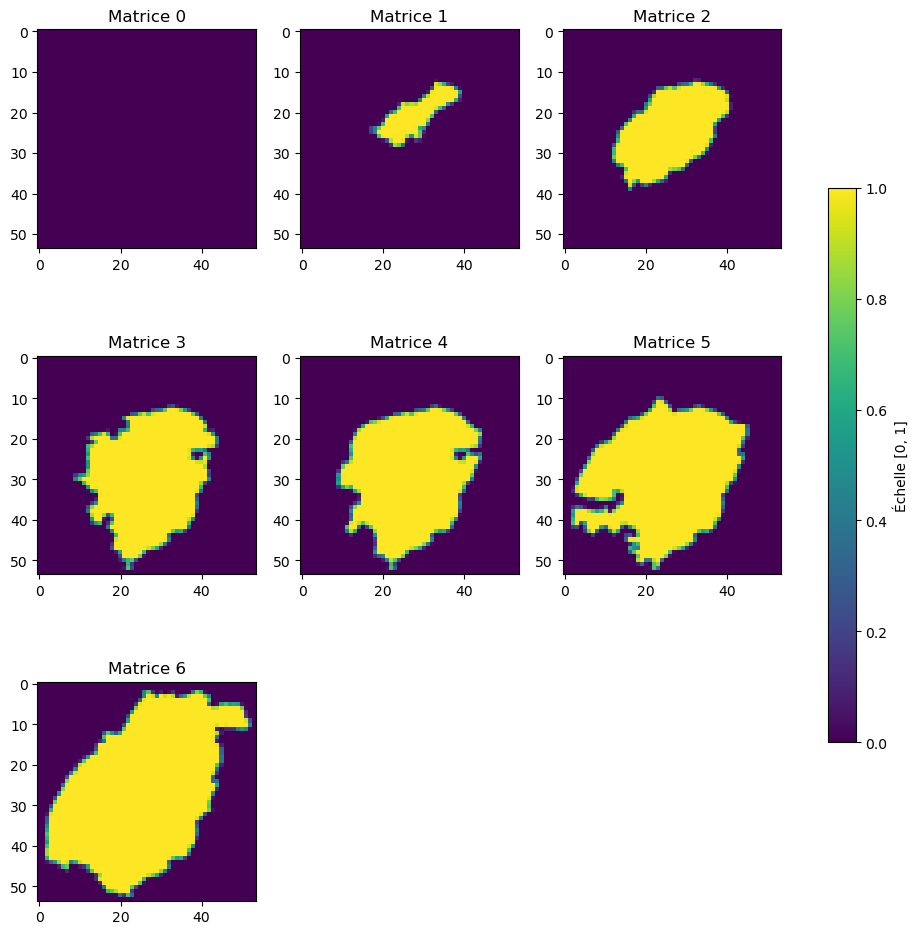

In [321]:
FireForestVizMatrix(45, 400, 200, gdf)